# Week 3 — Statistical Analysis of NIFTY 50

## Rolling Statistics

Rolling statistics are computed over a sliding window of time — in this analysis
we used 20-day and 60-day windows. Instead of computing a single number for the
entire dataset, rolling statistics show how a metric changes across different
periods. This lets us identify clusters of behavior — periods of high volatility,
poor returns, or strong risk-adjusted performance — that a single summary number
would completely hide.

## Rolling Volatility and Volatility Clustering

Rolling volatility is the standard deviation of returns computed over a rolling
window. It measures how volatile the index was during any given period.

When plotted over time, volatility is clearly not constant. It spikes sharply
during turbulent periods and stays low during calm periods. This phenomenon is
called volatility clustering — large moves tend to be followed by more large
moves, and calm periods tend to persist. This is one of the most well documented
empirical facts about financial markets.

In the NIFTY 50 data, a sharp volatility spike is visible around early 2020
during the COVID crash — daily moves were extreme in both directions during
that period.

## Rolling Sharpe Ratio

The Sharpe ratio measures whether returns justify the risk being taken:

    Sharpe = Annualised Mean Return / Annualised Volatility

A positive Sharpe means returns are compensating for risk. A negative Sharpe
means you are taking on risk and losing money.

The rolling Sharpe computed over a 20-day window is very noisy and hard to
interpret — because 20 data points is too few for the mean and volatility
estimates to be stable. Extending the window to 60 days smooths the ratio
significantly, making periods of sustained good and bad risk-adjusted performance
much clearer. More data points in the window means the estimates are less
sensitive to individual outlier days.

In [3]:
import pandas as pd
import numpy as np

data = pd.read_csv("C:\\Financial-Time-Series_Analysis\\data\\processed\\cleaned_data_with_returns.csv",
                   index_col='Date',
                   parse_dates=True)

print(data.head())
print(data.columns)

                  Close         High          Low         Open  Volume  \
Date                                                                     
2014-01-02  6221.149902  6358.299805  6211.299805  6301.250000  158100   
2014-01-03  6211.149902  6221.700195  6171.250000  6194.549805  139000   
2014-01-06  6191.450195  6224.700195  6170.250000  6220.850098  118300   
2014-01-07  6162.250000  6221.500000  6144.750000  6203.899902  138600   
2014-01-08  6174.600098  6192.100098  6160.350098  6178.049805  146900   

            simple_return_o2c  log_return_o2c  
Date                                           
2014-01-02          -0.012712       -0.012793  
2014-01-03           0.002680        0.002676  
2014-01-06          -0.004726       -0.004737  
2014-01-07          -0.006714       -0.006736  
2014-01-08          -0.000558       -0.000559  
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'simple_return_o2c',
       'log_return_o2c'],
      dtype='str')


In [4]:
returns = data['log_return_o2c']
window = 20  # 20-day rolling window

# Rolling mean of returns
rolling_mean = returns.rolling(window=window).mean()

# Rolling volatility (std of returns)
rolling_vol = returns.rolling(window=window).std()
# Annualise both (252 trading days in a year)
rolling_sharpe = (rolling_mean * 252) / (rolling_vol * np.sqrt(252))
print(rolling_mean.head(25))

Date
2014-01-02         NaN
2014-01-03         NaN
2014-01-06         NaN
2014-01-07         NaN
2014-01-08         NaN
2014-01-09         NaN
2014-01-10         NaN
2014-01-13         NaN
2014-01-14         NaN
2014-01-15         NaN
2014-01-16         NaN
2014-01-17         NaN
2014-01-20         NaN
2014-01-21         NaN
2014-01-22         NaN
2014-01-23         NaN
2014-01-24         NaN
2014-01-27         NaN
2014-01-28         NaN
2014-01-29   -0.001238
2014-01-30   -0.000543
2014-01-31   -0.000621
2014-02-03   -0.000857
2014-02-04   -0.000074
2014-02-05    0.000105
Name: log_return_o2c, dtype: float64


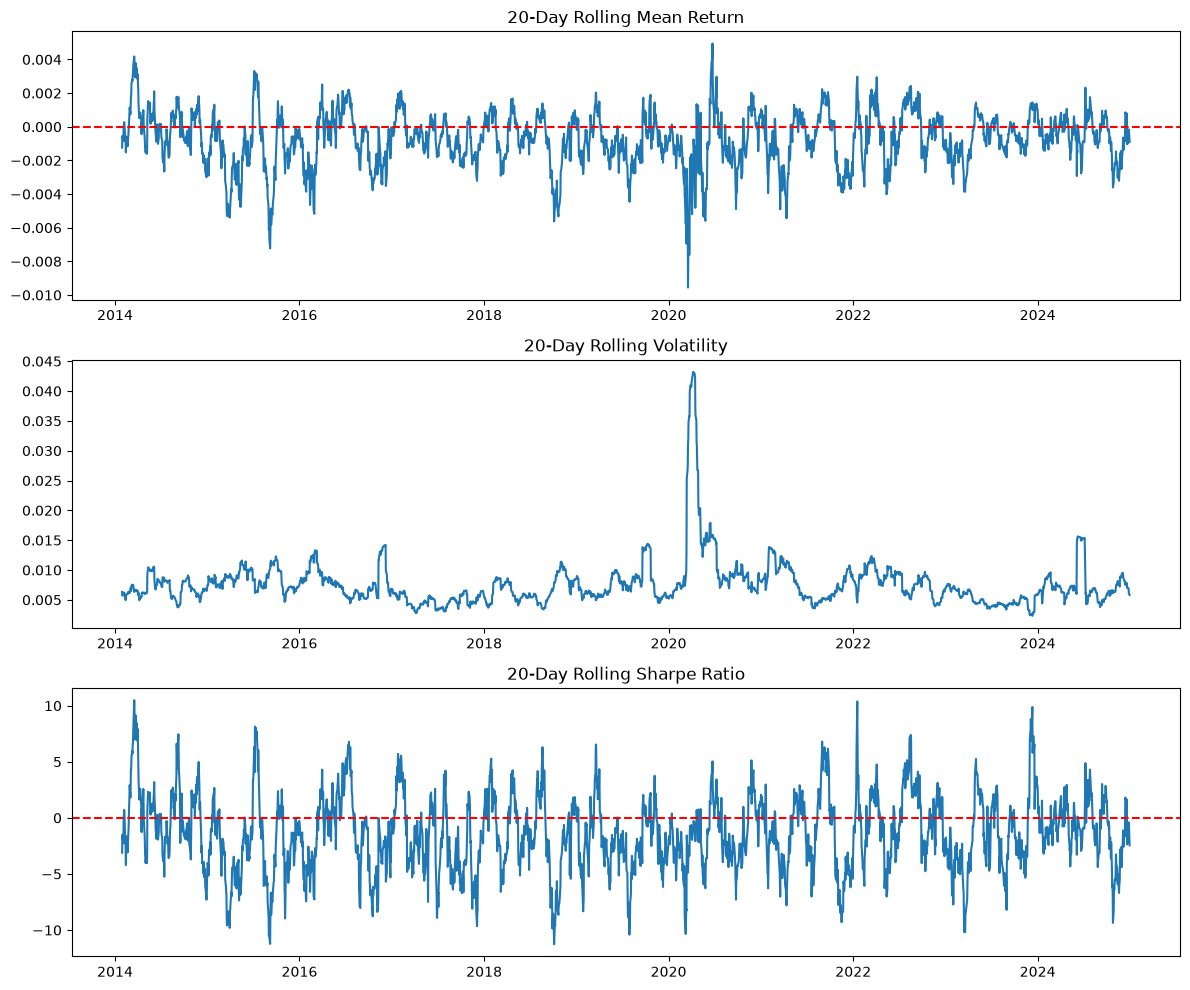

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1 - Rolling Mean
axes[0].plot(rolling_mean)
axes[0].set_title('20-Day Rolling Mean Return')
axes[0].axhline(y=0, color='red', linestyle='--')  # zero line for reference

# Plot 2 - Rolling Volatility
axes[1].plot(rolling_vol)
axes[1].set_title('20-Day Rolling Volatility')

# Plot 3 - Rolling Sharpe
axes[2].plot(rolling_sharpe)
axes[2].set_title('20-Day Rolling Sharpe Ratio')
axes[2].axhline(y=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

In [6]:
window_long = 60  # 60-day rolling window

rolling_mean_60 = returns.rolling(window=window_long).mean()
rolling_vol_60 = returns.rolling(window=window_long).std()
rolling_sharpe_60 = (rolling_mean_60 * 252) / (rolling_vol_60 * np.sqrt(252))

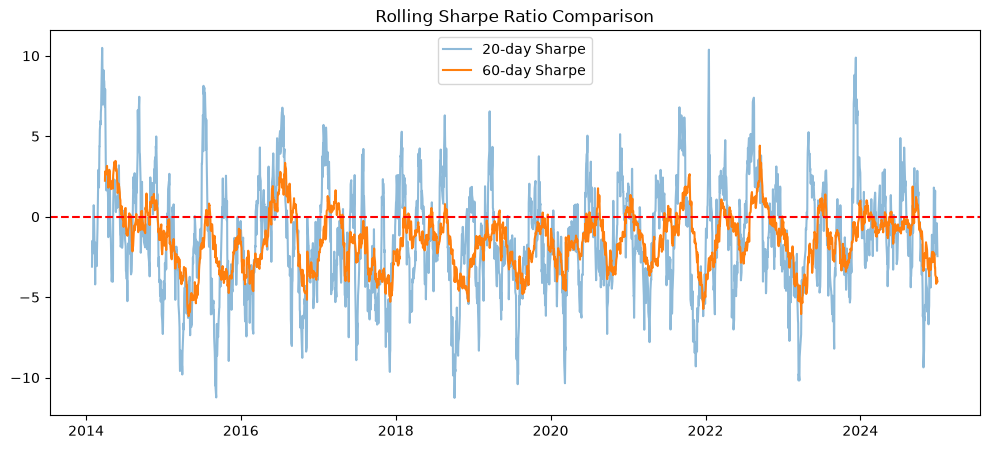

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(rolling_sharpe, alpha=0.5, label='20-day Sharpe')
plt.plot(rolling_sharpe_60, label='60-day Sharpe')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Sharpe Ratio Comparison')
plt.legend()
plt.show()

## Correlation — NIFTY 50 vs NIFTY BANK

To analyse cross-series correlation on a single index dataset, NIFTY BANK
(^NSEBANK) was pulled as a second series covering the same date range (2014-2024).

Both series were aligned on matching trading dates (2670 common rows) before
computing correlation on log returns.

Overall correlation: 0.7119 — a strong positive correlation. This makes sense
because:

- Banking stocks form a large weight within the NIFTY 50 index itself
- The health of the banking sector reflects broader economic health,
  affecting almost every sector

## Rolling Correlation

A single correlation number across 10 years hides how the relationship between
the two indices evolved over time. The 60-day rolling correlation shows the
relationship fluctuates — at some points the indices move almost in lockstep,
at others sector specific factors such as RBI policy, banking sector NPA crises,
and regulatory changes drive NIFTY BANK differently from the broader market.

This tells us the dependence between the two indices is real but not static —
assuming a fixed correlation would be an oversimplification for any serious
analysis.

In [8]:
import yfinance as yf

# Download data for a ticker
bank_data = yf.download(
    tickers="^NSEBANK",        # NIFTY 50 symbol
    start="2014-01-01",     # Start date
    end="2024-12-31",       # End date
    interval="1d"           # Daily data
)

bank_data.columns = bank_data.columns.droplevel(1)  

print("First 5 rows:")
print(bank_data.head())

print("\nShape (rows, columns):")
print(bank_data.shape)

print("\nColumn info:")
print(bank_data.info())

print("\nMissing values per column:")
print(bank_data.isnull().sum())



bank_data.to_csv("C:\\Financial-Time-Series_Analysis\\data\\raw\\nifty_bank_50_data.csv", index=True) 

[*********************100%***********************]  1 of 1 completed

First 5 rows:
Price              Close          High           Low          Open  Volume
Date                                                                      
2014-01-01  11385.466797  11432.416445  11360.867474  11418.767190   12100
2014-01-02  11183.070312  11578.765912  11150.070696  11383.667592   39900
2014-01-03  11181.520508  11207.869811  11052.471226  11098.121086   28200
2014-01-06  11048.920898  11174.219241  10996.821897  11174.219241   20500
2014-01-07  11036.622070  11153.970319  10892.024137  11097.671167   30300

Shape (rows, columns):
(2706, 5)

Column info:
<class 'pandas.DataFrame'>
DatetimeIndex: 2706 entries, 2014-01-01 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2706 non-null   float64
 1   High    2706 non-null   float64
 2   Low     2706 non-null   float64
 3   Open    2706 non-null   float64
 4   Volume  2706 non-null   int64  
dtypes: float64(4), int64(1)
memory usage

In [9]:
bank_returns = np.log(bank_data['Close'] / bank_data['Close'].shift(1))
bank_returns = bank_returns.dropna()

In [10]:
nifty_data = pd.read_csv("C:\\Financial-Time-Series_Analysis\\data\\processed\\cleaned_data_with_returns.csv",
                   index_col='Date',
                   parse_dates=True)

nifty_returns = nifty_data['log_return_o2c']

# Align — only keep dates present in both
combined = pd.DataFrame({
    'nifty': nifty_returns,
    'bank': bank_returns
}).dropna()

print(combined.shape)
print(combined.head())

(2670, 2)
               nifty      bank
Date                          
2014-01-02 -0.012793 -0.017937
2014-01-03  0.002676 -0.000139
2014-01-06 -0.004737 -0.011930
2014-01-07 -0.006736 -0.001114
2014-01-08 -0.000559  0.001535


In [11]:
corr_full = combined['nifty'].corr(combined['bank'])
print(f"Overall correlation between NIFTY 50 and NIFTY BANK: {corr_full:.4f}")

Overall correlation between NIFTY 50 and NIFTY BANK: 0.7119


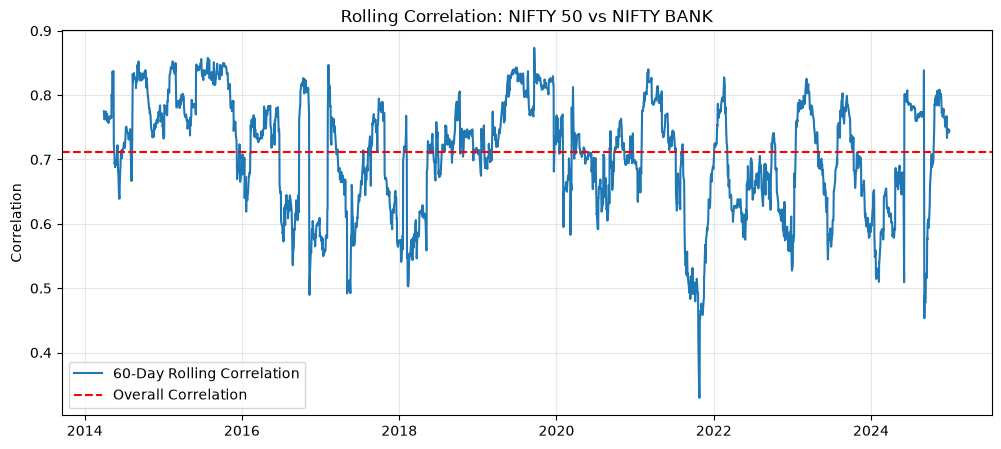

In [12]:
rolling_corr = combined['nifty'].rolling(window=60).corr(combined['bank'])
plt.figure(figsize=(12, 5))
plt.plot(rolling_corr, label='60-Day Rolling Correlation')
plt.axhline(y=corr_full, color='red', linestyle='--', label='Overall Correlation')
plt.title('Rolling Correlation: NIFTY 50 vs NIFTY BANK')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()